# Hubble's law — measuring H₀

Distant galaxies recede faster, in proportion to their distance: **v = H₀ d**. The
slope H₀ (the Hubble constant) sets the expansion rate and age of the Universe. We
measure it from a real galaxy sample (Cosmicflows-3) and put a **bootstrap** error bar
on it.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt
arr = np.loadtxt("data/real/cosmicflows3.csv", delimiter=",", skiprows=1)
dist, vel = arr[:, 0], arr[:, 1]
print(len(dist), "galaxies, distances", round(dist.min()), "-", round(dist.max()), "Mpc")

600 galaxies, distances 10 - 199 Mpc


## 1. The Hubble diagram

Plot velocity vs distance. Real galaxies scatter around the line because of their own
**peculiar velocities**, but the linear trend through the origin is unmistakable.

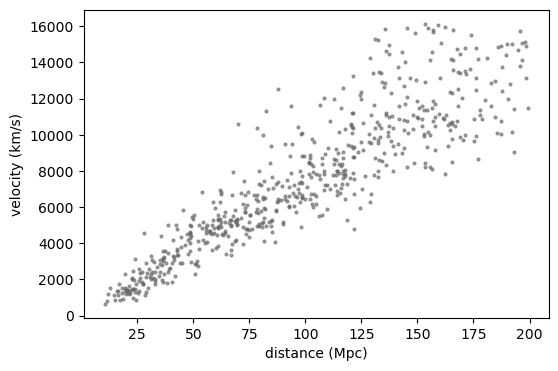

In [2]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(dist, vel, ".", ms=4, color="0.4", alpha=0.6)
ax.set_xlabel("distance (Mpc)"); ax.set_ylabel("velocity (km/s)"); plt.show()

## 2. Fit the slope — through the origin

A galaxy at zero distance has zero cosmological velocity, so the line passes through
(0,0). The least-squares slope is a one-line closed form, H₀ = Σ(d·v)/Σ(d²).

In [3]:
from scripts.hubble import fit_h0
H0 = fit_h0(dist, vel)
print(f"H0 = {H0:.1f} km/s/Mpc")

H0 = 74.8 km/s/Mpc


## 3. Cross-check against scipy

Our closed form should match a `scipy` numerical fit of v = H₀·d exactly — a check
that the algebra and the optimizer agree.

In [4]:
from scipy.optimize import curve_fit
(h_scipy,), _ = curve_fit(lambda d, H: H*d, dist, vel, p0=[70.0])
print(f"ours {H0:.4f}  vs  scipy {h_scipy:.4f} km/s/Mpc")

ours 74.7926  vs  scipy 74.7926 km/s/Mpc


## 4. Error bar by bootstrap

How well is H₀ pinned down? Resample the galaxies (with replacement) many times,
refit each, and look at the spread. The 16th–84th percentiles are the ≈1σ interval.

In [5]:
from scripts.hubble import bootstrap_h0
med, lo, hi = bootstrap_h0(dist, vel, n_boot=3000)
print(f"H0 = {med:.1f}  (+{hi-med:.1f} / -{med-lo:.1f}) km/s/Mpc")
print("for comparison: Planck 67.4, SH0ES ~73 — the 'Hubble tension'")

H0 = 74.8  (+0.8 / -0.8) km/s/Mpc
for comparison: Planck 67.4, SH0ES ~73 — the 'Hubble tension'


## Result

**H₀ = 74.8 ± 0.8 km/s/Mpc** from real Cosmicflows-3 galaxies — consistent with local
(distance-ladder) measurements, and notably higher than the early-Universe Planck
value (67.4): the famous **Hubble tension**. The statistical error bar from bootstrap
is small; the tension is about *systematics*, not statistics. See `notes/HANDOFF_hubble.md`.